In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# https://www.kaggle.com/datasets/lucidlenn/sloan-digital-sky-survey

Görünüm "PhotoObj" objıd = Nesne Tanımlayıcısı ra = J2000 Sağ Yükseliş (r bandı) aralık = J2000 Sapma (r bandı) Sağ yükseliş (kısaltılmış RA), göksel ekvator boyunca doğuya doğru Mart ekinoksundaki Güneş'ten dünya'nın üzerindeki noktanın saat çemberine kadar ölçülen açısal mesafedir söz konusu. Sapma ile eşleştirildiğinde (kısaltılmış aralık), bu astronomik koordinatlar, ekvator koordinat sistemindeki göksel küre üzerindeki bir noktanın (geleneksel olarak ingilizce olarak gökyüzü veya gökyüzü olarak adlandırılır) yönünü belirtir.

Kaynak: https://en.wikipedia.org/wiki/Right_ascension

u = DeV / Exp büyüklüğünden daha iyi uyum g = DeV / Exp büyüklüğünden daha iyi uyum r = DeV / Exp büyüklüğünden daha iyi uyum ı = DeV / Exp büyüklüğünden daha iyi uyum z = DEV / Exp büyüklüğünden daha iyi uyum Thuan-Gunn astronomik büyüklük sistemi. u, g, r, ı, z teleskopun 5 bandının tepkisini temsil eder.

İleri eğitim: https://www.astro.umd.edu/~ssm/ASTR620/mags.html

run = Çalışma Numarası, rereun = Tekrar Çalışma Numarası, camcol = Kamera Sütunu, field = Alan Numarası. Run, rerun, camcol ve field, SDSS tarafından çekilen bir görüntüdeki bir alanı tanımlayan özelliklerdir. Bir alan temel olarak tüm görüntünün 2048 x 1489 piksele karşılık gelen bir parçasıdır. Bir alan şu şekilde tanımlanabilir:

belirli taramayı, kamera sütununu veya "camcol" u tanımlayan çalışma numarası, çalışma içindeki tarama çizgisini ve alan numarasını tanımlayan 1'den 6'ya kadar olan bir sayıdır. Alan numarası tipik olarak 11'de başlar (ilk yükselme süresinden sonra) ve özellikle uzun koşular için 800 kadar büyük olabilir. Ek bir sayı, yeniden çalıştırma, görüntünün nasıl işlendiğini belirtir. "SpecObj" öğesini görüntüleyin specobjid = Nesne Tanımlayıcısı class = nesne sınıfı (galaksi, yıldız veya kuasar nesnesi) Sınıf, bir nesnenin galaksi, yıldız veya kuasar olduğunu belirtir. Bu, tahmin etmeye çalışacağımız yanıt değişkeni olacaktır.

redshift = Son kırmızıya kayma değeri plate = plaka numarası mjd = Gözlem tarihi MJD değeri fiberid = fiber kimliği

In [3]:
df = pd.read_csv("20-digitalskysurvey.csv")

In [4]:
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [5]:
columns_to_drop = ["objid","specobjid","rerun","camcol","field","run"]

In [6]:
df.drop(columns_to_drop, axis = 1, inplace=True)

In [7]:
df.head()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590,3306,54922,512


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  object 
 8   redshift  10000 non-null  float64
 9   plate     10000 non-null  int64  
 10  mjd       10000 non-null  int64  
 11  fiberid   10000 non-null  int64  
dtypes: float64(8), int64(3), object(1)
memory usage: 937.6+ KB


In [9]:
df['class'].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

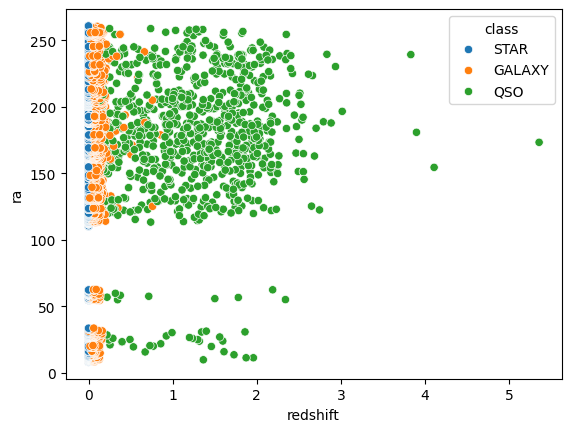

In [10]:
sns.scatterplot(data=df, x="redshift", y="ra", hue="class")
plt.show()

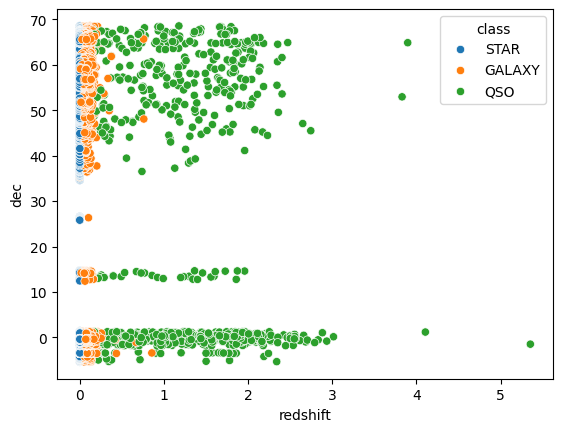

In [11]:
sns.scatterplot(data=df, x="redshift", y="dec", hue="class")
plt.show()

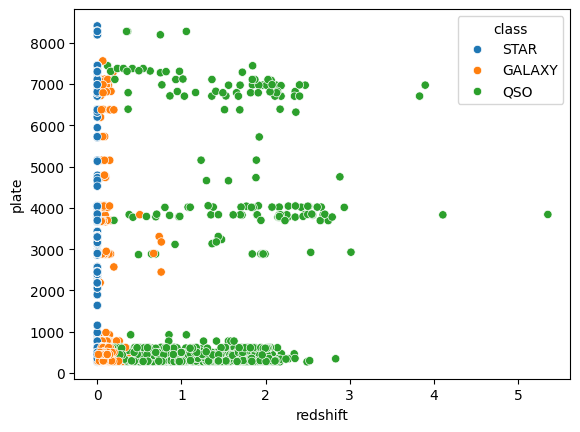

In [12]:
sns.scatterplot(data=df, x="redshift", y="plate", hue="class")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["class"] = le.fit_transform(df["class"])

In [14]:
df.head()


,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590,3306,54922,512


In [15]:
df.corr()

,ra,dec,u,g,r,i,z,class,redshift,plate,mjd,fiberid
ra,1.000000,0.003596,0.031238,0.043909,0.047103,0.045731,0.042950,-0.043219,0.030307,-0.095329,-0.086887,0.057485
dec,0.003596,1.000000,0.035279,0.061875,0.063404,0.058292,0.056870,-0.058918,0.067021,0.088342,0.066147,0.155012
u,0.031238,0.035279,1.000000,0.849232,0.692379,0.602630,0.551483,-0.269044,0.163741,-0.129430,-0.168793,0.011301
g,0.043909,0.061875,0.849232,1.000000,0.958106,0.907419,0.879622,-0.099212,0.407576,-0.054981,-0.092772,0.047187
r,0.047103,0.063404,0.692379,0.958106,1.000000,0.977672,0.969197,0.049628,0.441080,0.019787,-0.009345,0.061081
i,0.045731,0.058292,0.602630,0.907419,0.977672,1.000000,0.981507,0.146791,0.431450,0.072958,0.050896,0.069977
z,0.042950,0.056870,0.551483,0.879622,0.969197,0.981507,1.000000,0.215758,0.424034,0.112397,0.095658,0.067980
class,-0.043219,-0.058918,-0.269044,-0.099212,0.049628,0.146791,0.215758,1.000000,-0.075510,0.585495,0.648768,0.053593
redshift,0.030307,0.067021,0.163741,0.407576,0.441080,0.431450,0.424034,-0.075510,1.000000,-0.038091,-0.057957,0.046532
plate,-0.095329,0.088342,-0.129430,-0.054981,0.019787,0.072958,0.112397,0.585495,-0.038091,1.000000,0.966881,0.229811


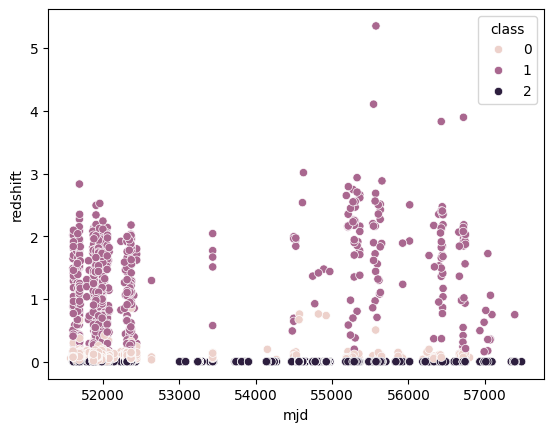

In [16]:
sns.scatterplot(data=df, x="mjd", y="redshift", hue="class")
plt.show()

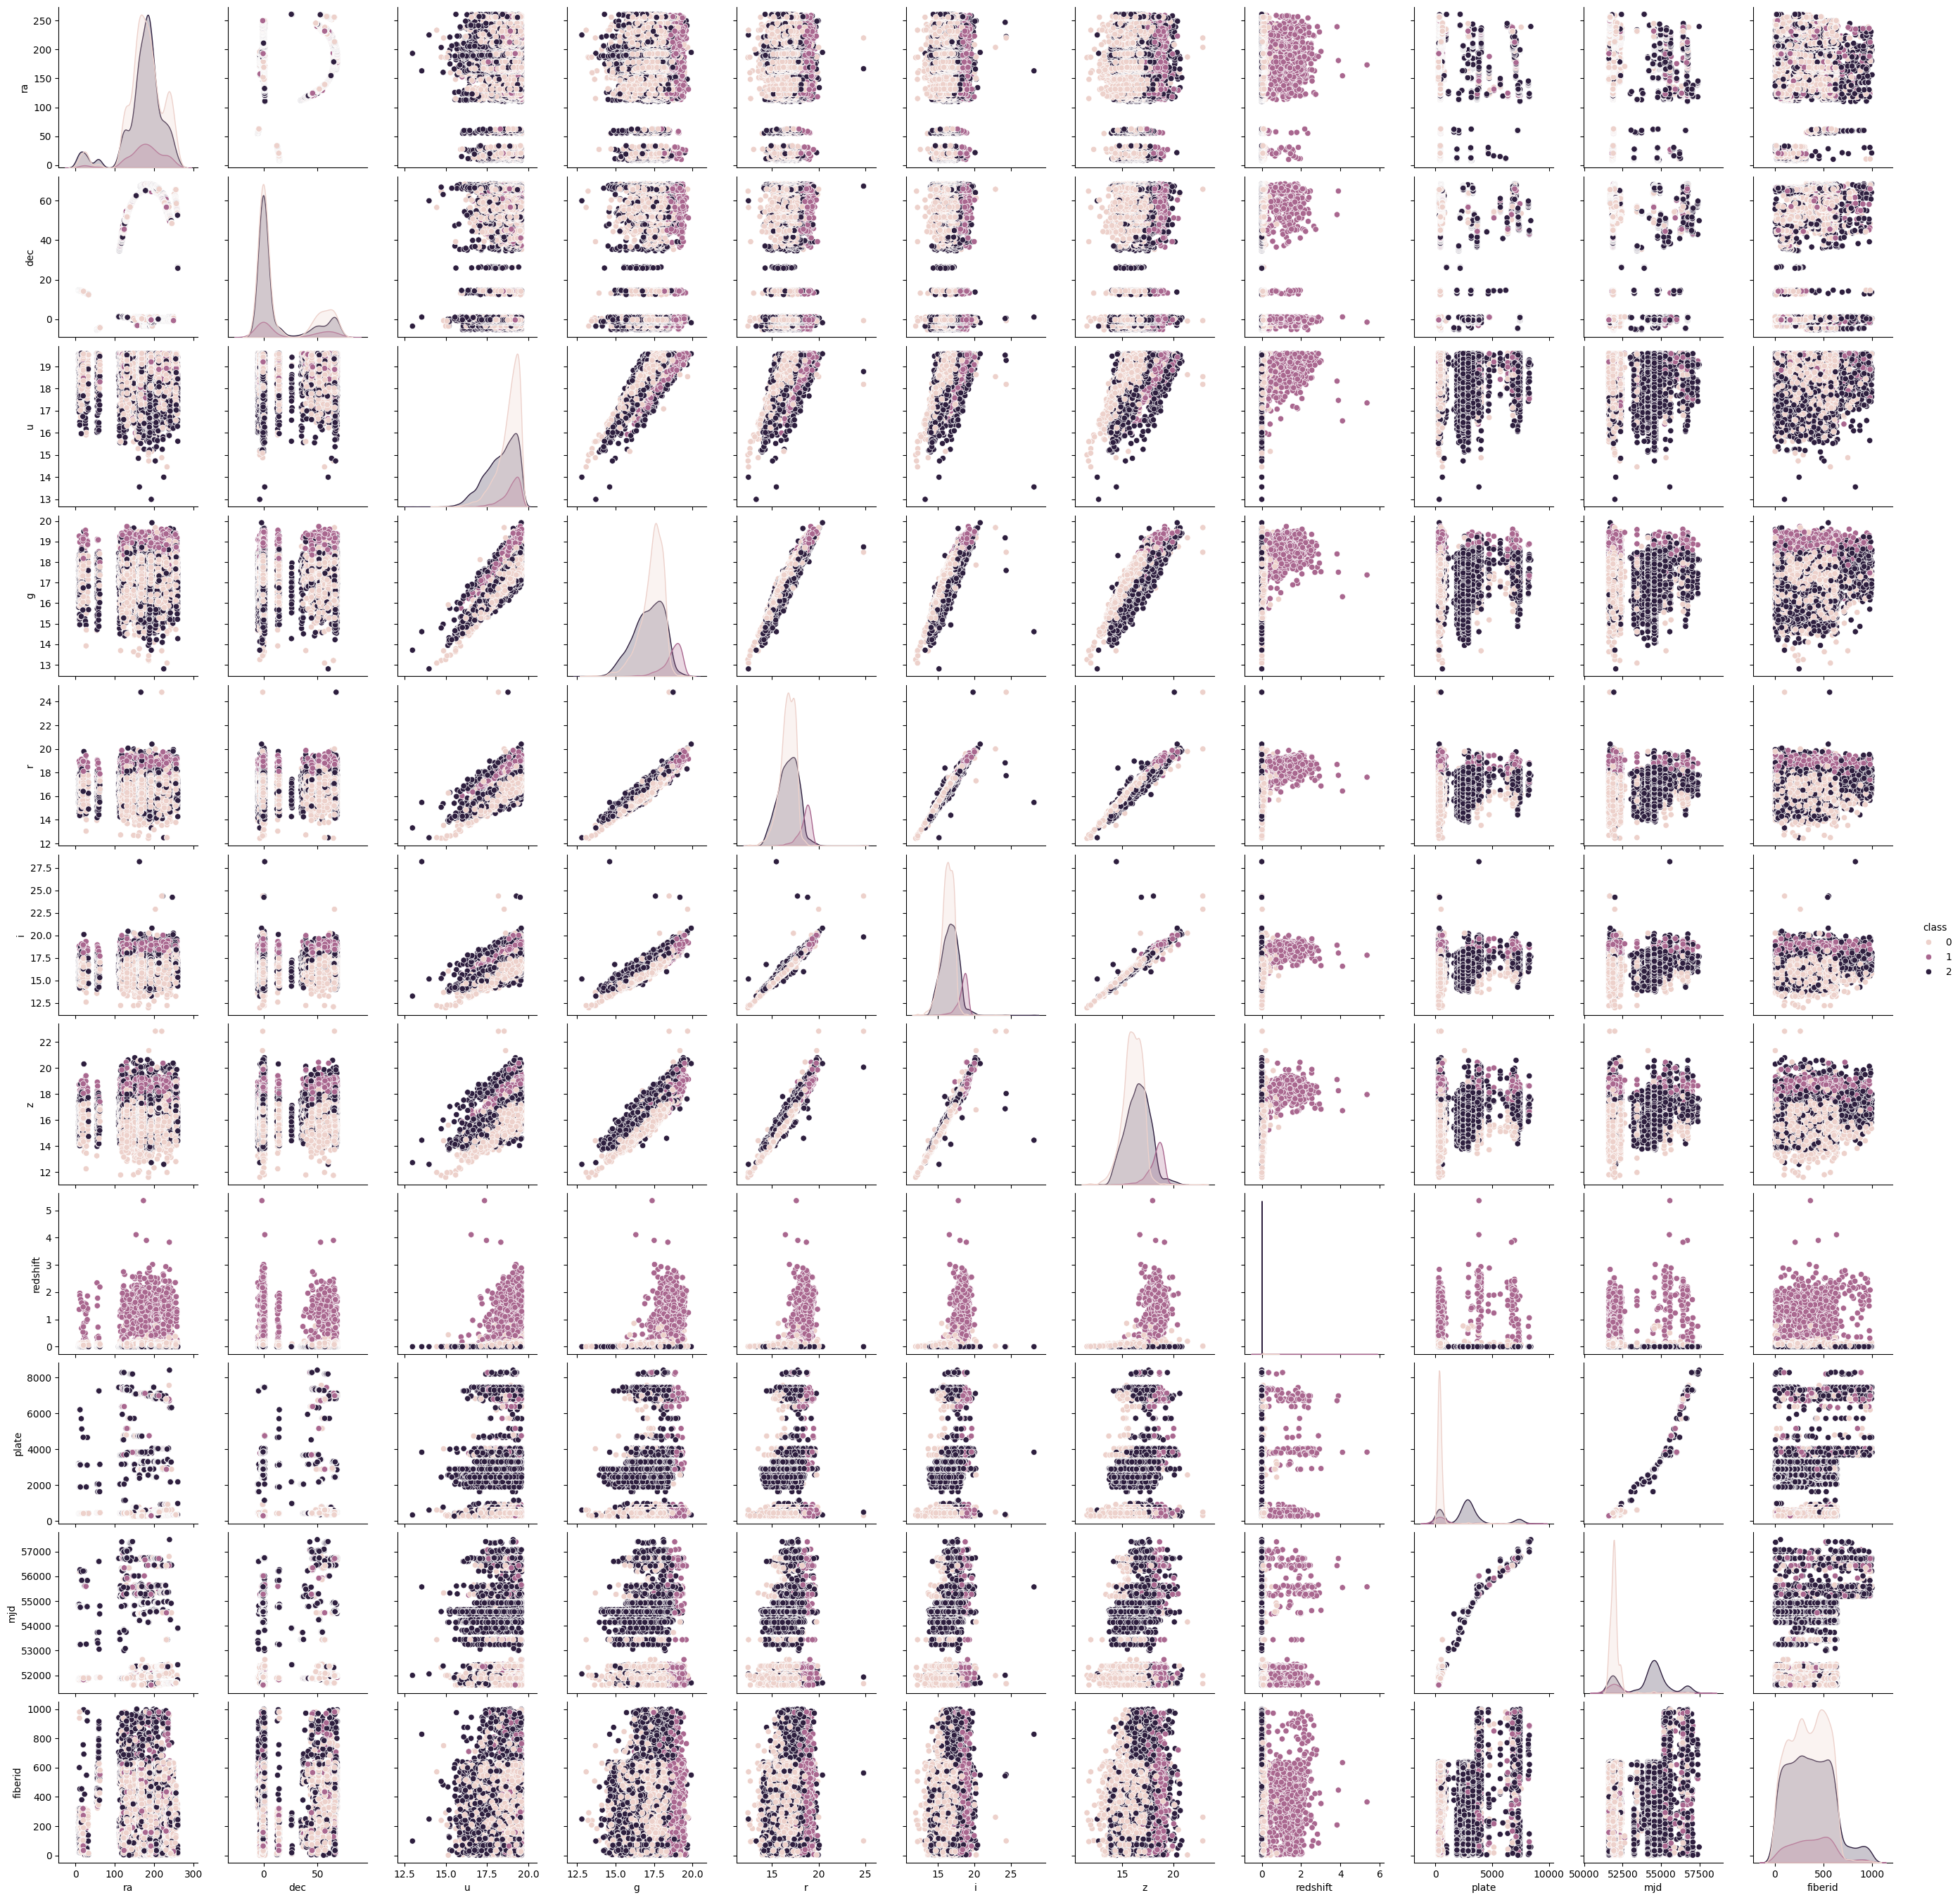

In [17]:
sns.pairplot(df, hue="class")
plt.show()

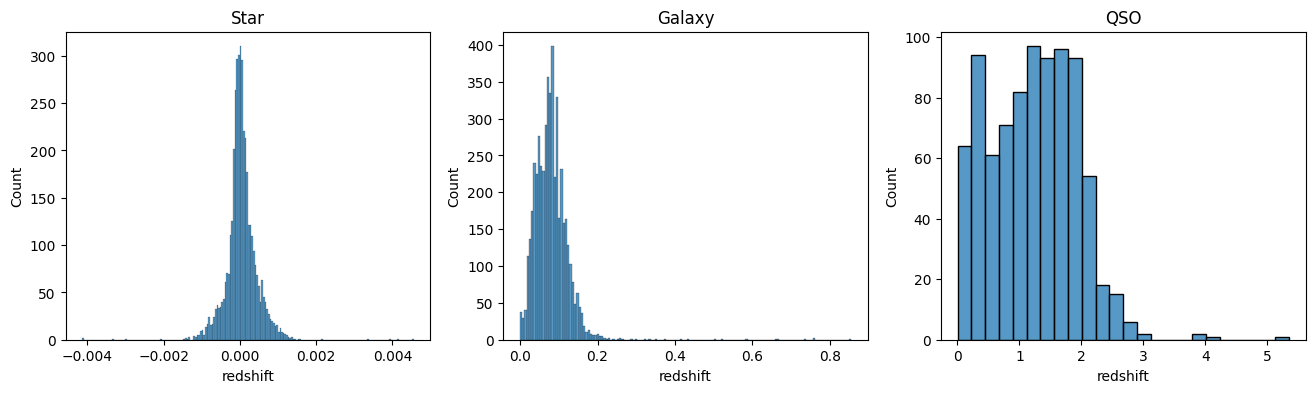

In [18]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(16,4))
ax = sns.histplot(df[df["class"] == 2].redshift, ax = axes[0])
ax.set_title("Star")
ax = sns.histplot(df[df["class"] == 0].redshift, ax = axes[1])
ax.set_title("Galaxy")
ax = sns.histplot(df[df["class"] == 1].redshift, ax = axes[2])
ax.set_title("QSO")
plt.show()

In [19]:
df["class"].value_counts()

class
0    4998
2    4152
1     850
Name: count, dtype: int64

In [20]:
X = df.drop("class", axis=1)
y = df["class"]

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 15)

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 1.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [31]:
from xgboost import XGBClassifier

In [32]:
xgb = XGBClassifier(n_estimators = 100)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [34]:

print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1667   17    3]
 [  13  253    0]
 [   7    1 1339]]
accuracy score:  0.9875757575757576
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1687
           1       0.93      0.95      0.94       266
           2       1.00      0.99      1.00      1347

    accuracy                           0.99      3300
   macro avg       0.97      0.98      0.98      3300
weighted avg       0.99      0.99      0.99      3300



In [35]:
params = {
        "n_estimators" : [100, 200, 300, 500],
        "learning_rate" : [0.01, 0.1],
        "max_depth" : [5,8,12,20,30],
        "colsample_bytree" : [0.3, 0.4, 0.5, 0.8, 1]
}

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
grid = GridSearchCV(estimator= XGBClassifier(), param_grid = params, cv=5, n_jobs = -1)

In [38]:
grid.fit(X_train, y_train)

/Users/tunahanbucak/Library/Python/3.9/lib/python/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1],
                         'learning_rate': [0.01, 0.1],
                         'max_depth': [5, 8, 12, 20, 30],
                         'n_estimators': [100, 200, 300, 500]})

In [39]:
grid.best_params_

{'colsample_bytree': 0.4,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 100}

In [40]:
y_pred = grid.predict(X_test)

In [41]:
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))
print("accuracy score: ", accuracy_score(y_pred, y_test))
print(classification_report(y_pred, y_test))

confusion matrix: 
 [[1668   19    1]
 [  10  251    0]
 [   9    1 1341]]
accuracy score:  0.9878787878787879
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1688
           1       0.93      0.96      0.94       261
           2       1.00      0.99      1.00      1351

    accuracy                           0.99      3300
   macro avg       0.97      0.98      0.98      3300
weighted avg       0.99      0.99      0.99      3300

